## **Tarea 2: Reducción de Dimensionalidad** 
### Modelos de Machine Learning No Supervisados

**Fecha de entrega martes 7 de abril.**

**Integrantes**
- Catalina Cornejo
- Hellen Quiñones
- Gustavo Sanchez


---

### 🌟🌟**Objetivo general**🌟🌟
Construir una representación de menor dimensión de los perfiles de estudiantes y comparar críticamente qué muestran (y qué no muestran) **PCA, t-SNE y UMAP**.

No basta con hacer figuras.  
La tarea busca que ustedes puedan:

1. preparar correctamente una matriz analítica
2. aplicar bien cada método
3. interpretar los resultados con cuidado
4. comparar fortalezas y limitaciones
5. discutir qué método parece más útil para este problema

#### **Importante**

Tal como en la Tarea 1, el foco no está sólo en "obtener un resultado", sino en evaluar si ese resultado representa perfiles útiles y comprensibles en el contexto de postulación y matrícula en educación superior.

--


### 🌟🌟**Detalles de la data**🌟🌟
Se trabajará con dos datasets:
- `matricula_completo.csv`
- `postulaciones_longer_1219.csv`


La **unidad de análisis final** deberá ser **`MRUNANIO`** (individuo-proceso). Por lo tanto, en la tabla de postulaciones deberemos agregar o resumir la información para que cada `MRUNANIO` quede representado por una sola fila en la base final.

---


### 🌟 **Parte 0:   Carga y preparación de datos**🌟
### 0.1. Librerias

Para esta sección se utilizarán los mismos archivos que para la Tarea 1, construyendo nuevamente una base a nivel de **`MRUNANIO`**.

#### **Requisitos mínimos de la base final**

- estar a nivel de `MRUNANIO`;
- contener sólo variables numéricas en la matriz final del modelo
- incluir al menos 12 variables
- estar reprocesada, limpia y estandarizada
- dejar claramente separadas las variables que usarán para modelar y las variables externas que usarán sólo para interpretar

Se debe dejar en claro:

- qué variables se conservaron
- cuáles se eliminaron
- qué cambios hicieron y por qué

Así que, en primer lugar cargamos las librerias

In [1]:
#  (\(\ 
# ( -.-)  Parte 0.1 - Librerías
# o_(")(")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness


#!pip install umap-learn

import umap.umap_ as umap

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

c:\Users\helle\miniforge3\envs\mlns-udd-2026\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 0.2. Variables escogidas
A continuación, y antes de construir la base analítica, debemos responder las siguientes preguntas:

1. ¿Qué variables se eligieron para representar el perfil del estudiante?
2. ¿Por qué esas variables son razonables para un análisis de reducción de dimensionalidad?
3. ¿Qué variables descartaron y por qué?
---

```
 (\(\ 
( -.-)  Respuesta 1 - ¿Qué variables eligieron para representar el perfil del estudiante?
o_(")(")
```


Para esta tarea se priorizaron las variables numéricas continuas y variables ordinales, ya que los métodos de reducción de dimensionalidad que se utilizarán en esta tarea (PCA, t-SNE y UMAP) se basan en el cálculo de distancias entre observaciones. Por lo que las variables que representan magnitudes permiten una interpretación más coherente de esas distancias.

Por otra parte, algunas variables categóricas fueron incorporadas mediante codificación one-hot, con el fin de evitar la imposición de un orden artificial entre sus categorías. Sin embargo, se restringió su uso a variables con un número reducido de niveles para no incrementar de manera exagerada la dimensionalidad del problema ni generar un desbalance en el impacto de estas variables dentro del modelo.

Teniendo en cuenta lo anterior, se seleccionaron 12 variables:

**===== Dimensión Académica =====================================================**

- `PUNTAJE_PONDERADO`

Puntaje ponderado de selección del postulante. Este va desde el 0 al 850, los números fuera de ese rango no se consideran ya que estos representan puntajes de admisiones especiales los cuales no demuestran un mejor puntaje si no que una categoría.

 Este es una variable con números continuos.


- `LUGAR`

Indica el puesto en que el estudiante fue matriculado en la carrera. Por ejemplo: 1 corresponde al primer matriculado, 20 al vigésimo, etc.

Esta es una variable de números enteros positivos.


- `PROMEDIO_NOTAS`

Promedio de notas de enseñanza media del estudiante.

Esta es una variable numérica continua.
  
- `PTJE_RANKING`

Puntaje asociado al ranking del estudiante dentro de su establecimiento escolar, este lo relaciona con sus pares

Esta es una variable numérica continua.



**===== Dimensión de Comportamiento de Postulación==================================**

- `coherence_5_0.05_`

Medida de coherencia del patrón de postulación del estudiante. Representa qué tan consistentes son las carreras que esocgió.

Esta es una variable numérica continua.

- `PREFERENCIA`

Indica el orden de preferencia de la carrera dentro de las postulaciones del estudiante. Un valor menor representa una opción con mayor prioridad. (TENER EN CUETA QUE EL 11 ES REPOSTULACIÓN)

Esta es una variable ordinal, ya que sus valores expresan un orden natural entre las preferencias.


**===== Dimensión Demográfica ===========================================**

- `Age`

Edad del estudiante al momento del proceso de admisión.

Esta es una variable numérica entera.

- `COD_SEXO`

Corresponde al sexo del estudiante (1 = Masculino, 2 = Femenino).
Corresponde al sexo del estudiante ONE HOT (0 = Masculino, 1 = Femenino).

Esta es una variable categórica de pocos niveles, que se puede incorporar sin necesidad de generar múltiples dimensiones adicionales, evitando así un desbalance en la estructura del modelo.


**=== Dimensión Socioeconómica y Familiar=============================**

- `INGRESO_BRUTO_FAM`

Corresponde al tramo de ingreso bruto del grupo familiar del estudiante.

Esta es una variable ordinal, ya que sus categorías representan niveles crecientes de ingreso familiar, aunque no corresponden a una escala continua exacta.
- `INGRESO_BRUTO_FAM`

Corresponde al tramo de ingreso bruto del grupo familiar del estudiante.

Esta es una variable ordinal, ya que sus categorías representan niveles crecientes de ingreso familiar.

- Valores:

    - 0: Sin información (eliminado del análisis)
    - 1: De 0 a 177.000
    - 2: De 177.001 a 270.000
    - 3: De 270.001 a 356.000
    - 4: De 356.001 a 470.000
    - 5: De 470.001 a 588.000
    - 6: De 588.001 a 722.000
    - 7: De 722.001 a 939.000
    - 8: De 939.001 a 1.220.000
    - 9: De 1.220.000 a 1.898.000
    - 10: De 1.898.001 o más

- `PERSONAS_ESTUDIAN_SUP`

Número de personas del grupo familiar que estudian en educación superior.

Esta es una variable numérica discreta.


- `GRUPO_FAMILIAR`

Número de integrantes del grupo familiar.

Esta es una variable numérica discreta.


- `CUANTOS_TRABAJAN_GRUPO_FAM`

Número de personas del grupo familiar que trabajan de manera remunerada.
(ojo que tiene dos dígitos)


```
 (\(\ 
( -.-)  Respuesta 2 - ¿Por qué esas variables son razonables para un análisis de reducción de dimensionalidad?
o_(")(")
```

Las variables son razonables para un análisis de reducción de dimensionalidad ya que se priorizó la elección de variables numéricas, lo que permite representar de manera más sencilla las distancias para que PCA, t-SNE y UMAP puedan trabajar de mejor manera ya que estas se basan en relaciones de cercanía o de similitud entre individuos.

SIguiendo con lo anterior, las variables continuas, como los puntajes y promedios, permiten observar diferencias de magnitud reales entre estudiantes, mientras que  por otro lado, las variables ordinales, como el ingreso familiar o la preferencia, mantienen un orden lógico que puede ser interpretado en términos de mayor o menor nivel. (Recordemos que las variables continuas toman valores numéricos en una escala real mientras que las ordinales representan categorías con un orden, pero sin distancias exactas entre ellas)

Además, se incluyó una variable categórica: `COD_SEXO` transformada mediante one-hot encoding. Lo que permite incorporar información demográfica relevante
 sin imponer un orden artificial entre las dos categorías.

Finalmente, como se pudo ver antes, la elección buscó curbrir diferentes dimensiones, entre ellas: académica, comportamiento, demográfica y socioeconómica, lo que permite una representación más completa del perfil.


```
 (\(\ 
( -.-)  Respuesta 3 - ¿Qué variables descartaron y por qué?
o_(")(")
```

Se descartaron variables que no eran adecuadas para un análisis basado en distancias.

En primer lugar, se eliminaron variables identificadoras como `MRUN`, `CODIGO_CARRERA`, `COD_INST`, `CODIGO_UNICO`, etc. Ya que estas son identificadores y no contienen información útil para describir características del estudiante.

También, se descartaron variables categóricas nominales con un alto número de niveles, como nombres de carreras, universidades o regiones. Estas variables, al ser transformadas mediante one-hot encoding, aumentarían exageradamente la dimensionalidad del dataset lo que podría generar un desbalance en la influencia de ciertas variables.

En comparación con la tarea 1, se decidió agregar `COD_SEXO`, incorporando  así una variable demográfica de baja dimensionalidad, evitando así el uso de codificación one-hot adicional.

Además, se evitaron variables con una alta cantidad de valores faltantes, como aquellas relacionadas con trabajo o condiciones específicas, ya que podrían afectar la calidad del análisis o requerir imputaciones poco confiables.

Se excluyeron variables redundantes o altamente correlacionadas, como múltiples puntajes que miden aspectos similares del rendimiento académico, con el fin de evitar duplicar información dentro del modelo.

C:\Users\helle\AppData\Local\Temp\ipykernel_22308\2342781784.py:2: DtypeWarning: Columns (0: LYC_ANTERIOR) have mixed types. Specify dtype option on import or set low_memory=False.
  df_matricula = pd.read_csv("matricula_completo.csv", sep=";", encoding="latin1")


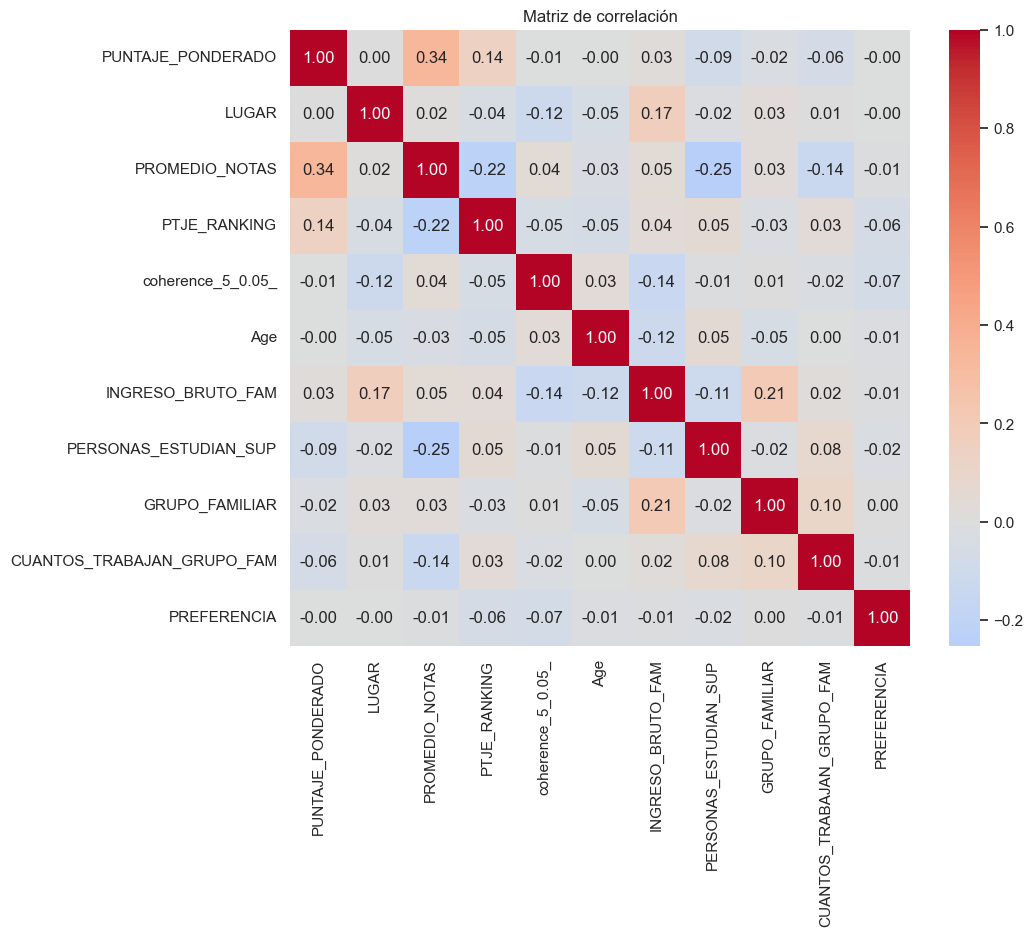

In [2]:
#para tener respaldo de correlaciones, crearemos una matriz de correlación con las variables seleccionadas. 
df_matricula = pd.read_csv("matricula_completo.csv", sep=";", encoding="latin1")

# Lista de variables seleccionadas, sin las categóricas
variables = [
    "PUNTAJE_PONDERADO",
    "LUGAR",
    "PROMEDIO_NOTAS",
    "PTJE_RANKING",
    "coherence_5_0.05_",
    "Age",
    "INGRESO_BRUTO_FAM",
    "PERSONAS_ESTUDIAN_SUP",
    "GRUPO_FAMILIAR",
    "CUANTOS_TRABAJAN_GRUPO_FAM",
    "PREFERENCIA",
]


df_sel = df_matricula[variables]
corr_matrix = df_sel.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()


Con lo anterior podemos demostrar (de manera superficial debido a la falta de limpieza) que no existen correlaciones evidentes en un comienzo.

Finalmente, se evitaron utilizar variables que serán utilizadas para el análisis posterior, como:

- `CAT_PERIODO_1` ¿La estructura depende de su permanencia en el primer año?

- `ANYO_PROCESO` ¿la estructura que aparece depende de cohortes o años específicos?

- `SIGLA_UNIVERSIDAD` ¿Algunos perfiles de estudiantes se concentran en universidades específicas?

- `GRUPO_DEPENDENCIA` Algunos perfiles de estudiantes se concentran en el tipo de establecimiento escolar de origen ?(1 Corporación Municipal, 2 Municipal, 3 Particular Subvencionado, 4 Particular Pagado, 5 Corporación de Administración Delegada, otros)
---



### 0.3. Construcción de la base analítica
Ahora se realizará casi de las misma forma que la tarea 1, la contrucción de la base analítica. En este primer paso, se realiza una nueva data filtrada con las variables requeridas para toda la tarea. Además se realizan correciones a siglas universitarias.

In [3]:
# Columnas definidas inicialmente por el archivo cols_to_use
cols_to_use = pd.read_csv('cols_to_use.csv')
cols_to_use.columns = ['col_name', 'flag']
cols = cols_to_use[cols_to_use['flag']==1]['col_name'].to_list()

# Leemos la tabla maestra (bruta)
full_table = pd.read_csv('matricula_completo.csv',  sep=';',
                         encoding="latin1")[cols]
# No son utiles (se eliminan las filas donde no tengan relleno el ID de las carreras)
full_table = full_table.dropna(subset=['GenericCareerID'])

# Corrección de siglas universidades (se transcriben los nombres)
sigla2rep = {'UANDE' : 'UANDES',
             'UAYSE' : 'UAYSEN',
             'UMAYO' : 'UMAYOR',
             'UPLA'  : 'UPA',
             'UANTOF': 'UANT',
             'UACh'  : 'UACH',
             'USM'   : 'UTFSM',
             'UACADEMIA' : 'UAHC'
             }
             
full_table['SIGLA_UNIVERSIDAD'] = full_table['SIGLA_UNIVERSIDAD'].replace(sigla2rep) #se reemplazan los nombres

# Mostrar primeras filas y columnas
print("")
print("Cantidad de filas y columnas")
print("Shape:", full_table.shape)
print("")
print("Columnas:", full_table.columns.tolist())
full_table.head()

C:\Users\helle\AppData\Local\Temp\ipykernel_22308\1524692383.py:7: DtypeWarning: Columns (0: LYC_ANTERIOR) have mixed types. Specify dtype option on import or set low_memory=False.
  full_table = pd.read_csv('matricula_completo.csv',  sep=';',



Cantidad de filas y columnas
Shape: (654986, 18)

Columnas: ['MRUNANIO', 'coherence_5_0.05_', 'CAT_PERIODO_1', 'ANYO_PROCESO', 'SIGLA_UNIVERSIDAD', 'PREFERENCIA', 'PUNTAJE_PONDERADO', 'LUGAR', 'COD_SEXO', 'GRUPO_DEPENDENCIA', 'PROMEDIO_NOTAS', 'PTJE_RANKING', 'GRUPO_FAMILIAR', 'CUANTOS_TRABAJAN_GRUPO_FAM', 'PERSONAS_ESTUDIAN_SUP', 'INGRESO_BRUTO_FAM', 'GenericCareerID', 'Age']


,MRUNANIO,coherence_5_0.05_,CAT_PERIODO_1,ANYO_PROCESO,SIGLA_UNIVERSIDAD,PREFERENCIA,PUNTAJE_PONDERADO,LUGAR,COD_SEXO,GRUPO_DEPENDENCIA,PROMEDIO_NOTAS,PTJE_RANKING,GRUPO_FAMILIAR,CUANTOS_TRABAJAN_GRUPO_FAM,PERSONAS_ESTUDIAN_SUP,INGRESO_BRUTO_FAM,GenericCareerID,Age
1,10000269-2012,0.166667,1,2012,UBB,1,56490,20,1,3.0,610.0,0,6,2,0,4,89.0,20
2,10000325-2012,0.200000,1,2012,UCH,2,68440,21,2,3.0,630.0,0,6,1,1,7,212.0,22
3,1000070-2012,0.666667,1,2012,UNAB,3,54460,47,2,1.0,550.0,0,4,1,0,11,204.0,20
4,10001229-2012,0.000000,1,2012,UBB,1,54290,40,1,2.0,580.0,0,2,1,0,1,192.0,23
5,1000146-2012,0.000000,1,2012,UNAB,1,57250,51,2,3.0,560.0,0,4,2,0,6,63.0,19


In [4]:
df_matricula_final = full_table 
#Podemos notar que el puntaje tiene un mal formato, lo corregiremos para que sea un puntaje decimal

# Si en algún  punto hay texto en vez de números, se transforma a Nan
df_matricula_final["PUNTAJE_PONDERADO"] = pd.to_numeric(df_matricula_final["PUNTAJE_PONDERADO"], errors="coerce") #si da error lo convierte en nan


# Se convierte la columna a float para que permita números decimales
df_matricula_final["PUNTAJE_PONDERADO"] = df_matricula_final["PUNTAJE_PONDERADO"].astype(float)


# En el caso de que algún puntaje estuviera bien escrito, haremos que los números > 1000, sean divididos por 100
porsiacaso = df_matricula_final["PUNTAJE_PONDERADO"] > 1000
df_matricula_final.loc[porsiacaso, "PUNTAJE_PONDERADO"] /= 100


df_matricula_final.loc[porsiacaso, "PUNTAJE_PONDERADO"].head(10)

1     564.90
2     684.40
3     544.60
4     542.90
5     572.50
6     635.65
7     539.50
8     647.65
9     622.10
10    610.10
Name: PUNTAJE_PONDERADO, dtype: float64

In [5]:
#Ahora comprobaremos que todas las variables numéricas efectivamente sean números y no texto, en caso de serlo, se reemplaza con Nan

df_matricula_final["coherence_5_0.05_"] = pd.to_numeric(df_matricula_final["coherence_5_0.05_"], errors="coerce")

df_matricula_final["LUGAR"] = pd.to_numeric(df_matricula_final["LUGAR"], errors="coerce")

df_matricula_final["Age"] = pd.to_numeric(df_matricula_final["Age"], errors="coerce")


In [6]:
#Se revisa cúantas variables son Nan

df_matricula_final.isna().sum() 

MRUNANIO                        0
coherence_5_0.05_             177
CAT_PERIODO_1                   0
ANYO_PROCESO                    0
SIGLA_UNIVERSIDAD               0
PREFERENCIA                     0
PUNTAJE_PONDERADO               0
LUGAR                           0
COD_SEXO                        0
GRUPO_DEPENDENCIA             758
PROMEDIO_NOTAS                156
PTJE_RANKING                    0
GRUPO_FAMILIAR                  0
CUANTOS_TRABAJAN_GRUPO_FAM      0
PERSONAS_ESTUDIAN_SUP           0
INGRESO_BRUTO_FAM               0
GenericCareerID                 0
Age                             0
dtype: int64

Se eliminaron las observaciones con valores faltantes en las variables seleccionadas. Dado que el conjunto de datos cuenta con aproximadamente 650.000 registros, y la cantidad de valores faltantes es menor al 0.2%, esta eliminación no afecta de manera significativa la representatividad ni la estructura general de los datos.

In [7]:
# Ver tamaño original
print("Antes:", df_matricula_final.shape)

# Eliminar filas con NA en variables seleccionadas
df_matricula_final = df_matricula_final.dropna(subset=variables)

# Ver tamaño final
print("Después:", df_matricula_final.shape)

Antes: (654986, 18)
Después: (654653, 18)


In [8]:
print(df_matricula_final["GRUPO_DEPENDENCIA"].value_counts())
#Dependencia tiene valores 0 y 6 como inválidos, se reemplazan por NaN para luego eliminar filas con NA en variables seleccionadas

# Reemplazar valores inválidos por NaN
df_matricula_final["GRUPO_DEPENDENCIA"] = df_matricula_final["GRUPO_DEPENDENCIA"].replace([0, 6], pd.NA)

# Eliminar filas con NA en variables seleccionadas
df_matricula_final = df_matricula_final.dropna(subset=variables)
print("después:")
print(df_matricula_final["GRUPO_DEPENDENCIA"].value_counts())

GRUPO_DEPENDENCIA
3.0    344479
4.0    144595
2.0    100413
1.0     48374
5.0     12260
0.0      3361
6.0       569
Name: count, dtype: int64
después:
GRUPO_DEPENDENCIA
3.0    344479
4.0    144595
2.0    100413
1.0     48374
5.0     12260
Name: count, dtype: int64


In [9]:
#borramos lo que quede con NA en variables seleccionadas
#Se revisa cúantas variables son Nan después de eliminar filas con NA en variables seleccionadas
df_matricula_final = df_matricula_final.dropna(subset=["GRUPO_DEPENDENCIA"])
df_matricula_final.isna().sum() 

MRUNANIO                      0
coherence_5_0.05_             0
CAT_PERIODO_1                 0
ANYO_PROCESO                  0
SIGLA_UNIVERSIDAD             0
PREFERENCIA                   0
PUNTAJE_PONDERADO             0
LUGAR                         0
COD_SEXO                      0
GRUPO_DEPENDENCIA             0
PROMEDIO_NOTAS                0
PTJE_RANKING                  0
GRUPO_FAMILIAR                0
CUANTOS_TRABAJAN_GRUPO_FAM    0
PERSONAS_ESTUDIAN_SUP         0
INGRESO_BRUTO_FAM             0
GenericCareerID               0
Age                           0
dtype: int64

In [10]:
# Buscamos los puntajes ponderados fuera del rango

fuera = (df_matricula_final["PUNTAJE_PONDERADO"] < 0) | (df_matricula_final["PUNTAJE_PONDERADO"] > 850)

print("Fuera de rango (0–850):", fuera.sum())
print("Total filas:", len(df_matricula_final))
print("Porcentaje fuera:", (fuera.mean()*100))

Fuera de rango (0–850): 81751
Total filas: 650121
Porcentaje fuera: 12.57473608758985


In [11]:
#vemos el máximo de cada año y notamos el error de conversión en 2017
df_matricula_final.groupby("ANYO_PROCESO")["PUNTAJE_PONDERADO"].max().sort_index()

ANYO_PROCESO
2012      836.65
2013      838.90
2014      840.10
2015      837.70
2016      928.00
2017    94790.00
2018      965.00
2019      969.00
Name: PUNTAJE_PONDERADO, dtype: float64

In [12]:
#aplicamos la conversión de formato nuevamente a puntaje ponderado
mask_x100 = df_matricula_final["PUNTAJE_PONDERADO"] > 1000
df_matricula_final.loc[mask_x100, "PUNTAJE_PONDERADO"] /= 100

# y repetimos todo de nuevo para comprobar cuántos datos quedaron ahora fuera del rango de los 850
fuera = (df_matricula_final["PUNTAJE_PONDERADO"] < 0) | (df_matricula_final["PUNTAJE_PONDERADO"] > 850)

print("Fuera de rango (0–850):", fuera.sum())
print("Total filas:", len(df_matricula_final))
print("")
print("Después de corrección, porcentaje fuera:")
# ahora solo nos quedaremos con las filas que estén dentro (no fuera) del rango, debido a que es un porcentaje menor en relación a la cantidad total de filas, y no es un porcentaje tan alto como para preocuparnos por perder información valiosa
df_matricula_final = df_matricula_final.loc[~fuera].copy()

print("Nuevas filas:", len(df_matricula_final))
print("Fuera de rango restante:", ((df_matricula_final["PUNTAJE_PONDERADO"] < 0) | (df_matricula_final["PUNTAJE_PONDERADO"] > 850)).sum())

Fuera de rango (0–850): 1530
Total filas: 650121

Después de corrección, porcentaje fuera:
Nuevas filas: 648591
Fuera de rango restante: 0


Se eliminaron los registros con `PREFERENCIA = 11`, ya que este valor corresponde a repostulación y no a una preferencia ordinal comparable con los valores 1 a 10.

In [13]:
# Ver cuántos casos hay
print((df_matricula_final["PREFERENCIA"] == 11).sum())

# Eliminar repostulación
df_matricula_final = df_matricula_final[df_matricula_final["PREFERENCIA"] != 11].copy()

print(df_matricula_final["PREFERENCIA"].value_counts().sort_index())

7188
PREFERENCIA
1     395992
2     135356
3      61629
4      24646
5      11972
6       5756
7       3007
8       1590
9        946
10       509
Name: count, dtype: int64


Se eliminaron los  "sin información" (0) del ingreso bruto familiar

In [14]:
# Contar específicamente los 0
print("Cantidad de 0:", (df_matricula_final["INGRESO_BRUTO_FAM"] == 0).sum())
df_matricula_final = df_matricula_final[df_matricula_final["INGRESO_BRUTO_FAM"] != 0].copy()
print("Cantidad de 0 después de eliminar:", (df_matricula_final["INGRESO_BRUTO_FAM"] == 0).sum())

Cantidad de 0: 6052
Cantidad de 0 después de eliminar: 0


---
Pasemos ahora a las postulaciones

In [15]:
# Ruta al archivo
ruta2 = 'postulaciones_longer_1219.csv'

# Cargar el dataset
df_postulaciones = pd.read_csv(ruta2, sep=';',  encoding="latin1")

# Eliminar columna "Unnamed: 0" si existe, si es que se cuela
if 'Unnamed: 0' in df_postulaciones.columns:
    df_postulaciones.drop(columns=['Unnamed: 0'], inplace=True) #si es verdad, haz el cambio sobre el mismo df

#CREAMOS MRUNANIO, como lo dijimos anteriormente para match con dataset matricula.
# Asegurarse de que MRUN y ANYO_PROCESO son strings, si no, con la suma se van a sumar jajaja

df_postulaciones['MRUN'] = df_postulaciones['MRUN'].astype(str)
df_postulaciones['ANYO_PROCESO'] = df_postulaciones['ANYO_PROCESO'].astype(str)

# Crear columna MRUNANIO
#este es igual a la columna de matrículas
df_postulaciones['MRUNANIO'] = df_postulaciones['MRUN'] + '-' + df_postulaciones['ANYO_PROCESO']

# Reordenar columnas: poner MRUNANIO al principio de la data
columnas = ['MRUNANIO'] + [col for col in df_postulaciones.columns if col != 'MRUNANIO']
df_postulaciones = df_postulaciones[columnas]


# Mostrar primeras filas y columnas
print("Shape:", df_postulaciones.shape)
print("Columnas:", df_postulaciones.columns.tolist())
df_postulaciones.head()

C:\Users\helle\AppData\Local\Temp\ipykernel_22308\3963893286.py:5: DtypeWarning: Columns (0: NOMBRE_CARRERA, 1: SEDE_CARRERA, 2: SIGLA_UNIVERSIDAD, 3: BEA) have mixed types. Specify dtype option on import or set low_memory=False.
  df_postulaciones = pd.read_csv(ruta2, sep=';',  encoding="latin1")


Shape: (4670560, 25)
Columnas: ['MRUNANIO', 'TIPO_IDENTIFICACION', 'MRUN', 'ANYO_PROCESO', 'SITUACION_POSTULANTE', 'PREFERENCIA', 'CODIGO_CARRERA', 'NOMBRE_CARRERA', 'SEDE_CARRERA', 'SIGLA_UNIVERSIDAD', 'ESTADO_PREFERENCIA', 'PUNTAJE', 'LUGAR', 'POND_ANYO_ACAD', 'BEA', 'Knowledge_Area ID', 'Knowledge_Area', 'OECD_Area ID', 'OECD_Area', 'OECD_Subarea ID', 'OECD_Subarea', 'Generic_Career ID', 'Generic_Career', 'Career', 'Students']


,MRUNANIO,TIPO_IDENTIFICACION,MRUN,ANYO_PROCESO,SITUACION_POSTULANTE,PREFERENCIA,CODIGO_CARRERA,NOMBRE_CARRERA,SEDE_CARRERA,SIGLA_UNIVERSIDAD,...,Knowledge_Area ID,Knowledge_Area,OECD_Area ID,OECD_Area,OECD_Subarea ID,OECD_Subarea,Generic_Career ID,Generic_Career,Career,Students
0,2950920-2012,C,2950920,2012,P,1,19086,ADMINISTRACIÓN HOTELERA Y GASTRONÓMICA,CASA CENTRAL,UV,...,2.0,Administración y Comercio,8.0,Servicios,21.0,Servicios Personales,2.0,Administracion Turistica y Hotelera,Administracion Hotelera y Gastronomica,912.0
1,2950920-2012,C,2950920,2012,P,2,16087,TECNOLOGO EN ADMINISTRACION DE PERSONAL (VESP),REGION METROPOLITANA,USACH,...,2.0,Administración y Comercio,3.0,"Ciencias Sociales, Enseñanza Comercial y Derecho",9.0,Enseñanza Comercial y Administración,36.0,Ingenieria en Recursos Humanos,Tecnologo en Administracion de Personal,241.0
2,2950920-2012,C,2950920,2012,P,3,41077,INGENIERÍA EN ADMINISTRACIÓN,VIÑA DEL MAR,UNAB,...,2.0,Administración y Comercio,3.0,"Ciencias Sociales, Enseñanza Comercial y Derecho",9.0,Enseñanza Comercial y Administración,25.0,Administracion de Empresas e Ing. Asociadas,Ingenieria en Administracion de Empresas,176.0
3,2950920-2012,C,2950920,2012,P,4,16038,CONTADOR PUBLICO Y AUDITOR-VESP,REGION METROPOLITANA,USACH,...,2.0,Administración y Comercio,3.0,"Ciencias Sociales, Enseñanza Comercial y Derecho",9.0,Enseñanza Comercial y Administración,17.0,Contador Auditor,Contador Publico y Auditor,541.0
4,22388130-2012,C,22388130,2012,P,1,15040,TECNICO UNIVERSITARIO EN INFORMATICA,SEDE VIÑA DEL MAR,UTFSM,...,1.0,Tecnología,2.0,Ciencias,13.0,Informática,46.0,Tecnico en Computacion e Informatica,Tecnico Universitario en Informatica,772.0


In [16]:
cols_a_mantener = ["MRUNANIO", "PREFERENCIA", "Generic_Career"]

df_postulaciones = df_postulaciones[cols_a_mantener].copy() #reescribe sobre si mismo

df_postulaciones.head()

,MRUNANIO,PREFERENCIA,Generic_Career
0,2950920-2012,1,Administracion Turistica y Hotelera
1,2950920-2012,2,Ingenieria en Recursos Humanos
2,2950920-2012,3,Administracion de Empresas e Ing. Asociadas
3,2950920-2012,4,Contador Auditor
4,22388130-2012,1,Tecnico en Computacion e Informatica


In [17]:
# ====== Parámetro de control ======
max_prefs = 3  

# ====== Paso 1: Asegurar tipos ======
df_postulaciones['PREFERENCIA'] = pd.to_numeric(df_postulaciones['PREFERENCIA'], errors='coerce') # Convertir a numérico, forzando errores a NaN

# ====== Paso 2: Filtrar solo las preferencias deseadas ======
df_filtrado = df_postulaciones[df_postulaciones['PREFERENCIA'].between(1, max_prefs)] # Filtrar solo las filas donde PREFERENCIA esté entre 1 y max_prefs

# ====== Paso 3: Pivotear ======
df_wide = df_filtrado.pivot_table( # Pivotear la tabla para tener una columna por cada preferencia
    index='MRUNANIO',
    columns='PREFERENCIA',
    values='Generic_Career',
    aggfunc='first'
)

# ====== Paso 4: Renombrar columnas ======
df_wide.columns = [f'Preferencia_{int(col)}' for col in df_wide.columns] # Renombrar columnas a Preferencia_1, Preferencia_2, etc.
df_wide = df_wide.reset_index()

# ====== Paso 5: Crear diccionario único de carreras ======
carreras_unicas = pd.Series(df_wide.drop(columns='MRUNANIO').values.ravel()).dropna().unique() # Obtener todas las carreras únicas (sin NaN)
mapa_carreras = {nombre: i for i, nombre in enumerate(sorted(carreras_unicas))} # Crear un diccionario que mapea cada carrera a un ID numérico

# ====== Paso 6: Codificación y normalización por preferencia ======
for col in [f'Preferencia_{i}' for i in range(1, max_prefs + 1)]: # Iterar sobre cada columna de preferencia
    if col in df_wide.columns: # Verificar que la columna exista (en caso de que max_prefs sea mayor que el número real de preferencias)
        df_wide[f'{col}_ID'] = df_wide[col].map(mapa_carreras) # Mapear cada carrera a su ID numérico
        df_wide[f'{col}_ID_Norm'] = df_wide[f'{col}_ID'] / len(mapa_carreras) # Normalizar dividiendo por el número total de carreras únicas

# ====== Resultado final ======
df_wide.head()

,MRUNANIO,Preferencia_1,Preferencia_2,Preferencia_3,Preferencia_1_ID,Preferencia_1_ID_Norm,Preferencia_2_ID,Preferencia_2_ID_Norm,Preferencia_3_ID,Preferencia_3_ID_Norm
0,10000020-2012,Nutricion y Dietetica,NaN,NaN,104.0,0.608187,NaN,NaN,NaN,NaN
1,10000026-2016,Pedagogia en Matematicas y Computacion,NaN,NaN,128.0,0.748538,NaN,NaN,NaN,NaN
2,10000097-2013,Medicina,Medicina,Medicina,101.0,0.590643,101.0,0.590643,101.0,0.590643
3,10000109-2017,"Ingenieria Civil, Plan Comun y Licenciatura en...",Arquitectura,Ingenieria Civil en Minas,61.0,0.356725,10.0,0.058480,57.0,0.333333
4,10000196-2014,Geologia,Ingenieria Civil en Minas,Ingenieria en Geomensura y Cartografia,38.0,0.222222,57.0,0.333333,78.0,0.456140


In [18]:
#Demostramos que hay 4 MRUNANIO que se repiten, es decir hay 8 valores.
print("Duplicados MRUNANIO matrícula:", df_matricula_final["MRUNANIO"].duplicated().sum())
print("Duplicados MRUNANIO wide:", df_wide["MRUNANIO"].duplicated().sum())

# Elimina completamente cualquier MRUNANIO duplicado (borra todos los repetidos)
#debido a la baja cantidad de duplicados, se decidió eliminar completamente los MRUNANIO que se repiten, esto para evitar problemas de match entre ambos datasets, ya que no se sabe cuál de los dos registros es el correcto.
df_matricula_final = df_matricula_final[~df_matricula_final["MRUNANIO"].duplicated(keep=False)].copy()

#comprobamos
print("Duplicados MRUNANIO:", df_matricula_final["MRUNANIO"].duplicated().sum())
print("Shape nueva:", df_matricula_final.shape)

Duplicados MRUNANIO matrícula: 3
Duplicados MRUNANIO wide: 0
Duplicados MRUNANIO: 0
Shape nueva: (635345, 18)


La variable `COD_SEXO` fue transformada a una variable binaria, ya que presenta solo dos categorías. Esto evita generar redundancia en la representación (como ocurre con one-hot encoding) y reduce la dimensionalidad del problema, lo cual es consistente con el objetivo del análisis.

In [19]:
sexo_dummies = pd.get_dummies(df_matricula_final["COD_SEXO"], prefix="SEXO")

df_matricula_final = pd.concat([df_matricula_final, sexo_dummies], axis=1)
df_matricula_final = df_matricula_final.drop(columns=["COD_SEXO"])

In [20]:
#usaremos "inner" para que los datos se solapen en el df_matrícula final, es decir, solo se unen si es que el MRUNANIO existe en ambos datasets

df_final = df_matricula_final.merge(df_wide, on="MRUNANIO", how="inner")
print("Matrícula:", df_matricula_final.shape)
print("Postulaciones wide:", df_wide.shape)
print("Final:", df_final.shape)

# cuántos MRUNANIO en común
print("MRUNANIO comunes:", df_matricula_final["MRUNANIO"].isin(df_wide["MRUNANIO"]).sum())
df_final.head()


Matrícula: (635345, 19)
Postulaciones wide: (957531, 10)
Final: (635345, 28)
MRUNANIO comunes: 635345


,MRUNANIO,coherence_5_0.05_,CAT_PERIODO_1,ANYO_PROCESO,SIGLA_UNIVERSIDAD,PREFERENCIA,PUNTAJE_PONDERADO,LUGAR,GRUPO_DEPENDENCIA,PROMEDIO_NOTAS,...,SEXO_2,Preferencia_1,Preferencia_2,Preferencia_3,Preferencia_1_ID,Preferencia_1_ID_Norm,Preferencia_2_ID,Preferencia_2_ID_Norm,Preferencia_3_ID,Preferencia_3_ID_Norm
0,10000269-2012,0.166667,1,2012,UBB,1,564.9,20,3.0,610.0,...,False,Pedagogia en Educacion Fisica,Pedagogia en Educacion Basica,Pedagogia en Educacion Fisica,121.0,0.707602,119.0,0.695906,121.0,0.707602
1,10000325-2012,0.200000,1,2012,UCH,2,684.4,21,3.0,630.0,...,True,Derecho,Licenciatura en Letras y Literatura,Derecho,27.0,0.157895,93.0,0.543860,27.0,0.157895
2,1000070-2012,0.666667,1,2012,UNAB,3,544.6,47,1.0,550.0,...,True,Bioquimica,Ingenieria Civil Bioquimica,Bioquimica,22.0,0.128655,43.0,0.251462,22.0,0.128655
3,10001229-2012,0.000000,1,2012,UBB,1,542.9,40,2.0,580.0,...,False,Pedagogia en Matematicas y Computacion,Pedagogia en Matematicas y Computacion,Pedagogia en Matematicas y Computacion,128.0,0.748538,128.0,0.748538,128.0,0.748538
4,1000146-2012,0.000000,1,2012,UNAB,1,572.5,51,3.0,560.0,...,True,Ingenieria Comercial,NaN,NaN,62.0,0.362573,NaN,NaN,NaN,NaN


Finalmente, en esta etapa 0 se realizarán los diferentes dataframes para la continuación del trabajo. Para ello, se tomó a MRUNANIO como índice:

- `df_final`: DataFrame con todos los datos (el de arriba)
- `df_train`: DataFrame para entrenamiento
- `df_analisis`: DataFrame para el análisis

In [21]:
# =========================
# 1. Variables seleccionadas para el modelo
# =========================

vars_train = [
    "MRUNANIO",
    "PUNTAJE_PONDERADO",
    "LUGAR",
    "PROMEDIO_NOTAS",
    "PTJE_RANKING",
    "coherence_5_0.05_",
    "PREFERENCIA",
    "Age",
    "SEXO_1",
    "SEXO_2",
    "INGRESO_BRUTO_FAM",
    "PERSONAS_ESTUDIAN_SUP",
    "GRUPO_FAMILIAR",
    "CUANTOS_TRABAJAN_GRUPO_FAM"
]

# =========================
# 2. Variables para análisis posterior
# =========================

vars_analisis = [
    "MRUNANIO",
    "CAT_PERIODO_1",
    "ANYO_PROCESO",
    "SIGLA_UNIVERSIDAD",
    "GRUPO_DEPENDENCIA"
]

# =========================
# 3. Crear dataframes separados
# =========================

df_train = df_final[vars_train].copy()
df_analisis = df_final[vars_analisis].copy()

# =========================
# 4. Revisar dimensiones
# =========================

print("df_train:", df_train.shape)
print("df_analisis:", df_analisis.shape)

# =========================
# 5. Revisar primeras filas
# =========================

display(df_train.head())
display(df_analisis.head())

df_train: (635345, 14)
df_analisis: (635345, 5)


,MRUNANIO,PUNTAJE_PONDERADO,LUGAR,PROMEDIO_NOTAS,PTJE_RANKING,coherence_5_0.05_,PREFERENCIA,Age,SEXO_1,SEXO_2,INGRESO_BRUTO_FAM,PERSONAS_ESTUDIAN_SUP,GRUPO_FAMILIAR,CUANTOS_TRABAJAN_GRUPO_FAM
0,10000269-2012,564.9,20,610.0,0,0.166667,1,20,True,False,4,0,6,2
1,10000325-2012,684.4,21,630.0,0,0.200000,2,22,False,True,7,1,6,1
2,1000070-2012,544.6,47,550.0,0,0.666667,3,20,False,True,11,0,4,1
3,10001229-2012,542.9,40,580.0,0,0.000000,1,23,True,False,1,0,2,1
4,1000146-2012,572.5,51,560.0,0,0.000000,1,19,False,True,6,0,4,2


,MRUNANIO,CAT_PERIODO_1,ANYO_PROCESO,SIGLA_UNIVERSIDAD,GRUPO_DEPENDENCIA
0,10000269-2012,1,2012,UBB,3.0
1,10000325-2012,1,2012,UCH,3.0
2,1000070-2012,1,2012,UNAB,1.0
3,10001229-2012,1,2012,UBB,2.0
4,1000146-2012,1,2012,UNAB,3.0


Dado el gran tamaño de la base de datos, se trabajó con una muestra aleatoria de 15.000 observaciones para hacer computacionalmente más eficiente la aplicación de PCA, t-SNE y UMAP. Esta muestra se considera representativa, ya que su tamaño sigue siendo amplio en relación con el total de registros y fue obtenida mediante un muestreo aleatorio simple. Además, se fijó una semilla (`random_state = 42`) para garantizar la reproducibilidad del procedimiento.

In [23]:
############
# Definimos X para estandarizar y modelar, pero antes guardamos el identificador aparte para luego poder unir con el df_analisis, esto porque el modelo no puede tener variables categóricas ni texto, pero el df_analisis sí, por lo que separamos el identificador para luego unir ambos dataframes usando ese identificador.
############

# Guardamos identificador aparte
ids = df_train["MRUNANIO"].copy()

# Quitamos identificador para modelar
X = df_train.drop(columns=["MRUNANIO"]).copy()

# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Volver a DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=df_train.index)

############
# Para facilitar el análisis posterior, creamos una muestra aleatoria de 15000 filas del df_train, y filtramos el df_analisis para que solo contenga los MRUNANIO que están en la muestra, esto para que luego podamos unir ambos dataframes usando el identificador MRUNANIO y así tener toda la información de la muestra en un solo dataframe para análisis posteriores.
############

RANDOM_STATE = 42

# Muestra aleatoria de 15000 filas
df_train_s = df_train.sample(n=15000, random_state=RANDOM_STATE).copy()

# Filtrar análisis usando los mismos MRUNANIO
df_analisis_s = df_analisis[df_analisis["MRUNANIO"].isin(df_train_s["MRUNANIO"])].copy()

############}
#Estandarizamos solo los de la muestra 
############


X_sample = df_train_s.drop(columns=["MRUNANIO"]).copy()

scaler = StandardScaler()
X_sample_scaled = scaler.fit_transform(X_sample)

X_sample_scaled = pd.DataFrame(
    X_sample_scaled,
    columns=X_sample.columns,
    index=df_train_s.index
)

### 🌟 Importante en esta etapa 0🌟
Con ello, ya se estandarizaron los datos, con lo cuál se deberá utilizar:

- `df_final`: DataFrame con todas las columnas
- `df_train_s`: DataFrame para entrenamiento, solo las 12 variables , de 15.000 muestras (filas)
- `df_analisis_s`: DataFrame para el análisis posterior, 4 variables, de 15.000 muestras
- `X_sample_scaled` Los 15.000 datos ya estandarizados

### 0.4. Preguntas post construcción
A continuación, y después de construir la base analítica, debemos responder las siguientes preguntas:

4. ¿Cómo trataron valores faltantes?
5. ¿Qué variables dejaron sólo para interpretación externa?


```
 (\(\ 
( -.-)  Respuesta 4 - ¿Cómo trataron valores faltantes?
o_(")(")
```
Los valores faltantes fueron tratados mediante eliminación de registros incompletos en las variables seleccionadas. En particular, se eliminaron categorías que representaban ausencia de información, como por ejemplo, el valor 0 en `INGRESO_BRUTO_FAM`, el 11 de `PREFERENCIA` o los valores fuera de rango de `PUNTAJE_PONDERADO`, entre otros. Dado el gran tamaño del dataset, de aproximadamente 650.000 registros, la eliminación de estos casos no afecta de manera significativa la representatividad de la muestra.

```
 (\(\ 
( -.-)  Respuesta 5 - ¿Qué variables dejaron sólo para interpretación externa?
o_(")(")
```
Las variables `CAT_PERIODO_1`, `ANYO_PROCESO`, `SIGLA_UNIVERSIDAD` y `GRUPO_DEPENDENCIA` fueron reservadas para análisis e interpretación posterior. Estas no se incluyeron en los modelos de reducción de dimensionalidad, ya que son variables categóricas o contextuales que no aportan directamente al cálculo de distancias, pero sí permiten caracterizar y comprender los patrones observados en los resultados. Su significado fue explicado anteriormente en la elección de variables.

---

# Parte 1: PCA

En clases vimos que **PCA** es un método **lineal** que busca nuevas direcciones ortogonales que maximicen la varianza, y que es especialmente útil cuando hay **correlación** o **redundancia** entre variables. 

En esta parte deben usar PCA para responder una pregunta central:

> **¿Qué tan bien puede resumirse la estructura de esta base en pocos componentes principales?**

## Instrucciones

1. Ajusten PCA sobre la matriz estandarizada.
2. Calculen la **varianza explicada** por cada componente.
3. Hagan un **scree plot**.
4. Calculen la **varianza acumulada**.
5. Indiquen cuántos componentes se necesitan para llegar aproximadamente a:
   - 70%
   - 80%
   - 90%
6. Obtengan la proyección en **2 dimensiones**.
7. Revisen los **loadings** de PC1 y PC2.
8. Interpreten qué podría representar cada componente.

## Preguntas guía

- ¿PCA parece resumir bien la información?
- ¿Las primeras componentes son interpretables?
- ¿Las variables parecen estar midiendo dimensiones redundantes?

In [ ]:
# ==========================================
# Parte 1.1 - Ajustar PCA completo
# ==========================================

# pca_full = PCA()
# X_pca_full = pca_full.fit_transform(X_scaled)

# var_exp = pca_full.explained_variance_ratio_
# var_exp_acum = np.cumsum(var_exp)

# resumen_pca = pd.DataFrame({
#     "Componente": np.arange(1, len(var_exp) + 1),
#     "Varianza explicada": var_exp,
#     "Varianza acumulada": var_exp_acum
# })

# resumen_pca.head(10)

In [ ]:
# ==========================================
# Parte 1.2 - Scree plot
# ==========================================

# plt.figure(figsize=(8, 4))
# plt.plot(np.arange(1, len(var_exp) + 1), var_exp, marker="o")
# plt.xlabel("Número de componente")
# plt.ylabel("Proporción de varianza explicada")
# plt.title("Scree plot - PCA")
# plt.show()

In [ ]:
# ==========================================
# Parte 1.3 - PCA en 2 dimensiones
# ==========================================

# pca_2 = PCA(n_components=2, random_state=RANDOM_STATE)
# X_pca_2 = pca_2.fit_transform(X_scaled)

# df_pca = pd.DataFrame(X_pca_2, columns=["PC1", "PC2"], index=X.index)
# df_pca.head()

In [ ]:
# ==========================================
# Parte 1.4 - Loadings
# ==========================================

# loadings = pd.DataFrame(
#     pca_2.components_.T,
#     index=columnas_modelo,
#     columns=["PC1", "PC2"]
# )

# display(loadings.sort_values("PC1", ascending=False))
# display(loadings.sort_values("PC2", ascending=False))

In [ ]:
# ==========================================
# Parte 1.5 - Gráfico PCA
# ==========================================

# plt.figure(figsize=(7, 6))
# sns.scatterplot(data=df_pca, x="PC1", y="PC2", s=35)
# plt.title("Proyección 2D con PCA")
# plt.show()

### 1.6. Interpretación obligatoria

Respondan brevemente:

1. ¿Qué porcentaje de la varianza explican PC1 y PC2?
2. ¿Parece razonable usar sólo dos componentes para visualizar el dataset?
3. ¿Qué variables cargan más fuerte en PC1?
4. ¿Qué variables cargan más fuerte en PC2?
5. ¿Qué interpretación sustantiva le darían a PC1 y PC2?

```
 (\(\ 
( -.-)  Respuesta 1
o_(")(")
```

```
 (\(\ 
( -.-)  Respuesta 2
o_(")(")
```

```
 (\(\ 
( -.-)  Respuesta 3
o_(")(")
```


```
 (\(\ 
( -.-)  Respuesta 4
o_(")(")
```

```
 (\(\ 
( -.-)  Respuesta 5
o_(")(")
```

--

# Parte 2: t-SNE

En clases vimos que **t-SNE** intenta preservar **vecindades locales**: puntos que son cercanos en el espacio original deberían seguir relativamente cerca en la proyección. Pero **no debe interpretarse como una representación fiel de distancias globales**.

En esta parte deben estudiar cómo cambia el resultado de t-SNE al variar sus parámetros.

## Instrucciones

1. Apliquen t-SNE sobre la misma matriz estandarizada.
2. Prueben **al menos 3 valores de `perplexity`**.
3. Mantengan fijo `random_state`.
4. Comparen visualmente las proyecciones.
5. Discutan qué estructuras parecen estables y cuáles no.

## Valores sugeridos

- `perplexity = 5`
- `perplexity = 30`
- `perplexity = 50`

## Preguntas guía

- ¿Qué tan sensible es t-SNE al parámetro `perplexity`?
- ¿Se observan grupos o sólo nubes?
- ¿Qué sería riesgoso sobreinterpretar en estos gráficos?

In [ ]:
# ==========================================
# Parte 2.1 - t-SNE con distintos valores
# ==========================================

perplexities = [5, 30, 50]
tsne_resultados = {}

for p in perplexities:
    # Ajusten si el tamaño muestral no permite alguno de estos valores
    tsne = TSNE(
        n_components=2,
        perplexity=p,
        random_state=RANDOM_STATE,
        init="pca",
        learning_rate="auto",
        max_iter=1000
    )

    # X_tsne = tsne.fit_transform(X_scaled)
    # tsne_resultados[p] = pd.DataFrame(X_tsne, columns=["Dim1", "Dim2"], index=X.index)

In [ ]:
# ==========================================
# Parte 2.2 - Visualización comparada t-SNE
# ==========================================

# fig, axes = plt.subplots(1, len(tsne_resultados), figsize=(5 * len(tsne_resultados), 4))

# if len(tsne_resultados) == 1:
#     axes = [axes]

# for ax, (p, df_plot) in zip(axes, tsne_resultados.items()):
#     sns.scatterplot(data=df_plot, x="Dim1", y="Dim2", ax=ax, s=30)
#     ax.set_title(f"t-SNE (perplexity = {p})")

# plt.tight_layout()
# plt.show()

## 2.3. Interpretación obligatoria

Respondan brevemente:

1. ¿Qué cambia al variar `perplexity`?
2. ¿Qué patrones parecen robustos a distintos valores?
3. ¿Qué patrones cambian demasiado como para confiar plenamente en ellos?
4. ¿Por qué no conviene interpretar las distancias entre grupos en t-SNE como si fueran “distancias reales” del dataset original?
5. ¿Les parece útil t-SNE para este problema? ¿Por qué?

--

# Parte 3: UMAP

En clases vimos que **UMAP** también busca preservar estructura local, pero suele comportarse de manera distinta a t-SNE, y permite controlar el equilibrio entre estructura local y global mediante parámetros como `n_neighbors` y `min_dist`.

En esta parte deben explorar cómo cambian las proyecciones de UMAP al modificar esos parámetros.

## Instrucciones

1. Apliquen UMAP sobre la misma matriz estandarizada.
2. Prueben **al menos 3 combinaciones** de:
   - `n_neighbors`
   - `min_dist`
3. Comparen visualmente los resultados.
4. Discutan qué configuraciones muestran más agrupamiento y cuáles muestran una estructura más continua.

## Configuraciones sugeridas

- `n_neighbors = 10`, `min_dist = 0.0`
- `n_neighbors = 30`, `min_dist = 0.1`
- `n_neighbors = 50`, `min_dist = 0.5`

## Preguntas guía

- ¿Qué efecto parece tener `n_neighbors`?
- ¿Qué efecto parece tener `min_dist`?
- ¿Qué proyección les parece más informativa?

In [ ]:
# ==========================================
# Parte 3.1 - UMAP con distintas configuraciones
# ==========================================

config_umap = [
    {"n_neighbors": 10, "min_dist": 0.0},
    {"n_neighbors": 30, "min_dist": 0.1},
    {"n_neighbors": 50, "min_dist": 0.5},
]

umap_resultados = {}

for cfg in config_umap:
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=cfg["n_neighbors"],
        min_dist=cfg["min_dist"],
        random_state=RANDOM_STATE
    )

    # X_umap = reducer.fit_transform(X_scaled)
    # umap_resultados[(cfg["n_neighbors"], cfg["min_dist"])] = pd.DataFrame(
    #     X_umap, columns=["Dim1", "Dim2"], index=X.index
    # )

In [ ]:
# ==========================================
# Parte 3.2 - Visualización comparada UMAP
# ==========================================

# fig, axes = plt.subplots(1, len(umap_resultados), figsize=(5 * len(umap_resultados), 4))

# if len(umap_resultados) == 1:
#     axes = [axes]

# for ax, ((nn, mdist), df_plot) in zip(axes, umap_resultados.items()):
#     sns.scatterplot(data=df_plot, x="Dim1", y="Dim2", ax=ax, s=30)
#     ax.set_title(f"UMAP (n_neighbors={nn}, min_dist={mdist})")

# plt.tight_layout()
# plt.show()

## 3.3. Interpretación obligatoria

Respondan brevemente:

1. ¿Qué cambia al aumentar `n_neighbors`?
2. ¿Qué cambia al modificar `min_dist`?
3. ¿Qué configuraciones producen grupos más compactos?
4. ¿Qué configuraciones muestran una estructura más continua?
5. ¿UMAP les parece más útil que t-SNE en este caso? Expliquen.

--

# Parte 4: Comparación entre métodos

Tal como en la Tarea 1, aquí no basta con aplicar métodos: deben hacer una **comparación crítica entre ellos**.

Ahora la comparación no es entre algoritmos de clustering, sino entre técnicas de reducción de dimensionalidad.

## Instrucciones

Comparen **PCA, t-SNE y UMAP** en términos de:

1. **interpretabilidad**;
2. **capacidad de visualización**;
3. **sensibilidad a parámetros**;
4. **preservación de estructura local**;
5. **utilidad para este problema**.

Pueden complementar con la métrica **trustworthiness** si lo desean.

In [ ]:
# ==========================================
# Parte 4.1 - Comparación opcional con trustworthiness
# ==========================================

# resultados_metricas = []

# resultados_metricas.append({
#     "Método": "PCA_2D",
#     "Trustworthiness_k10": trustworthiness(X_scaled, X_pca_2, n_neighbors=10)
# })

# for p, df_plot in tsne_resultados.items():
#     resultados_metricas.append({
#         "Método": f"t-SNE_perp_{p}",
#         "Trustworthiness_k10": trustworthiness(X_scaled, df_plot.values, n_neighbors=10)
#     })

# for (nn, mdist), df_plot in umap_resultados.items():
#     resultados_metricas.append({
#         "Método": f"UMAP_nn{nn}_md{mdist}",
#         "Trustworthiness_k10": trustworthiness(X_scaled, df_plot.values, n_neighbors=10)
#     })

# pd.DataFrame(resultados_metricas).sort_values("Trustworthiness_k10", ascending=False)

In [ ]:
 ==========================================
# Parte 4.2 - Tabla comparativa final
# ==========================================

comparacion = pd.DataFrame({
    "Método": ["PCA", "t-SNE", "UMAP"],
    "¿Interpretable?": ["", "", ""],
    "¿Sensible a parámetros?": ["", "", ""],
    "¿Útil para estructura local?": ["", "", ""],
    "¿Útil para este problema?": ["", "", ""],
    "Comentario final": ["", "", ""]
})

comparacion

IndentationError: unexpected indent (973889161.py, line 1)

## 4.3. Preguntas obligatorias

1. ¿Qué método les pareció más interpretable?
2. ¿Qué método les pareció más útil para exploración visual?
3. ¿Qué método mostró mayor sensibilidad a los parámetros?
4. ¿Qué método recomendarían para este problema y por qué?
5. ¿Qué advertencias metodológicas harían a alguien que mire sólo los gráficos?

---

# Parte 5: Interpretación sustantiva

Tal como en la Tarea 1, la idea no es quedarse en el resultado matemático, sino traducirlo en **perfiles o patrones significativos**.

Usen una o más variables externas para interpretar las proyecciones.

### Ejemplos posibles

- `CAT_PERIODO_1`
- puntaje ponderado
- coherencia de postulaciones
- preferencia de ingreso
- lugar de matrícula
- dependencia escolar
- edad
- alguna etiqueta de cluster de la Tarea 1, si quieren usarla como referencia externa

In [ ]:
# ==========================================
# Parte 5.1 - Ejemplo de unión con variables externas
# ==========================================

# Ejemplo:
# df_pca_plot = df_pca.join(df_final[variables_externas])

# df_pca_plot.head()

In [ ]:
# ==========================================
# Parte 5.2 - Ejemplo de gráfico coloreado por variable externa
# ==========================================

# plt.figure(figsize=(7, 6))
# sns.scatterplot(
#     data=df_pca_plot,
#     x="PC1", y="PC2",
#     hue="CAT_PERIODO_1",
#     alpha=0.7
# )
# plt.title("PCA coloreado por CAT_PERIODO_1")
# plt.show()

## 5.3. Preguntas obligatorias

1. ¿Aparecen perfiles o gradientes con sentido sustantivo?
2. ¿Alguna variable externa parece ordenarse de manera clara en alguna proyección?
3. ¿Qué diferencias observan entre interpretar con PCA versus interpretar con t-SNE o UMAP?
4. ¿Ven patrones útiles o sólo separaciones visuales difíciles de explicar?

---

# Parte 6: Discusión final

Respondan brevemente:

1. ¿Qué diferencia conceptual central encontraron entre PCA y los métodos no lineales?
2. ¿Qué aprendieron sobre el efecto de los parámetros en t-SNE?
3. ¿Qué aprendieron sobre el efecto de los parámetros en UMAP?
4. ¿Qué método les pareció más convincente para este dataset?
5. ¿Qué limitaciones tiene estudiar un dataset sólo mediante proyecciones en 2D?
6. ¿Qué análisis complementarían esta tarea si quisieran profundizar más?

---

# Entregable: HTML

Debe tener:

1. **Notebook en Jupyter** con código, resultados e interpretación.
2. **Base analítica final** o código reproducible para construirla.
3. **Visualizaciones claras y bien etiquetadas** de PCA, t-SNE y UMAP.
4. **Comparación crítica entre métodos**.
5. **Interpretación sustantiva** de los patrones observados.

Tal como en la Tarea 1, se espera un notebook **ordenado**, con figuras legibles y argumentos claros.